# 04 - Bus backup strategies and recovery after closures

**Demonstration (about three minutes).** Start with the layered map, then close
the Airport Line and compare the five strategies at the frozen two-link budget.
Switch to a Bayswater closure and step through its failure rounds, where the
full candidate pool closes eight extra rail facilities before the cascade stops.

This notebook reads the committed P2.3 tables under `results/recovery/`; it
does not rerun `make recovery`. The frozen inputs are 21 closure scenarios, five
strategies on one two-link budget, a 266-link standby pool, and the ported
layered cascade from alpha 0 to 2 in steps of 0.05.

In [1]:
from pathlib import Path
import sys
import time
from io import BytesIO

started = time.perf_counter()
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / 'src/transperth/config.py').is_file())
sys.path.insert(0, str(ROOT / 'src'))

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import Image, display

from transperth.config import FIGURES_DIR
from transperth.network import load_rail_graph
from transperth.notebook_support import verify_processed, read_result
from transperth.plotting import apply_style

manifest = verify_processed(ROOT)
rail = load_rail_graph()
apply_style()
NOTEBOOK_FIGURES = FIGURES_DIR / 'notebook04'
NOTEBOOK_FIGURES.mkdir(parents=True, exist_ok=True)


def show_figure(fig, name):
    """Display ``fig`` and save a PNG copy under figures/notebook04."""
    buffer = BytesIO()
    fig.savefig(buffer, format='png', dpi=150, bbox_inches='tight')
    data = buffer.getvalue()
    (NOTEBOOK_FIGURES / name).write_bytes(data)
    display(Image(data=data))
    plt.close(fig)


strategy_table = read_result(ROOT, 'results/recovery/strategy_comparison.csv')
scan = read_result(ROOT, 'results/recovery/bus_cascade_scan.csv')
comparison = read_result(ROOT, 'results/recovery/bus_cascade_comparison.csv')
history = read_result(ROOT, 'results/recovery/bus_cascade_history.csv')
loads = read_result(ROOT, 'results/recovery/bus_cascade_loads.csv')
scenarios = read_result(ROOT, 'results/recovery/scenario_manifest.csv')
candidates = read_result(ROOT, 'results/multilayer/gtfs_backup_candidates.csv')
manual = pd.read_csv(ROOT / 'data/processed/backup_edges.csv',
                     dtype={'station_a': str, 'station_b': str})

assert len(strategy_table) == 105 and strategy_table.strategy.nunique() == 5
assert sorted(strategy_table.budget.unique()) == [2]
assert len(scenarios) == 21 and len(scan) == 369 and len(comparison) == 246
assert len(candidates) == 263 and len(manual) == 4

summary = pd.DataFrame([
    {'table': 'strategy_comparison.csv', 'rows': len(strategy_table),
     'content': '21 scenarios x 5 strategies at a 2-link budget'},
    {'table': 'bus_cascade_scan.csv', 'rows': len(scan),
     'content': '3 triggers x 41 tolerances x 3 bus sets'},
    {'table': 'bus_cascade_comparison.csv', 'rows': len(comparison),
     'content': 'paired bus-minus-rail deltas'},
    {'table': 'bus_cascade_loads.csv', 'rows': len(loads),
     'content': 'per-round loads of the traced cases'},
    {'table': 'gtfs_backup_candidates.csv', 'rows': len(candidates),
     'content': 'GTFS-derived standby pairs'},
])
display(summary)

,table,rows,content
0,strategy_comparison.csv,105,21 scenarios x 5 strategies at a 2-link budget
1,bus_cascade_scan.csv,369,3 triggers x 41 tolerances x 3 bus sets
2,bus_cascade_comparison.csv,246,paired bus-minus-rail deltas
3,bus_cascade_loads.csv,3081,per-round loads of the traced cases
4,gtfs_backup_candidates.csv,263,GTFS-derived standby pairs


## The layered network

Each station has a persistent terminal `T:i` and a closable rail facility `R:i`.
Rail edges join facilities, and standby bus edges join terminals, so closing a
rail facility leaves its terminal connected to whatever buses reach it. Access
between the two takes one assumed minute ([docs/model.md, section 5](../docs/model.md)).

The standby pool is the union of 263 GTFS-derived candidate pairs and the four
manually verified pairs, minus one duplicate (Bayswater to Perth, where the
manual time wins). A candidate pair comes from a single selected bus trip whose
two stops sit within 400 m of different stations. A link is endpoint evidence,
not a road geometry or a timetable.

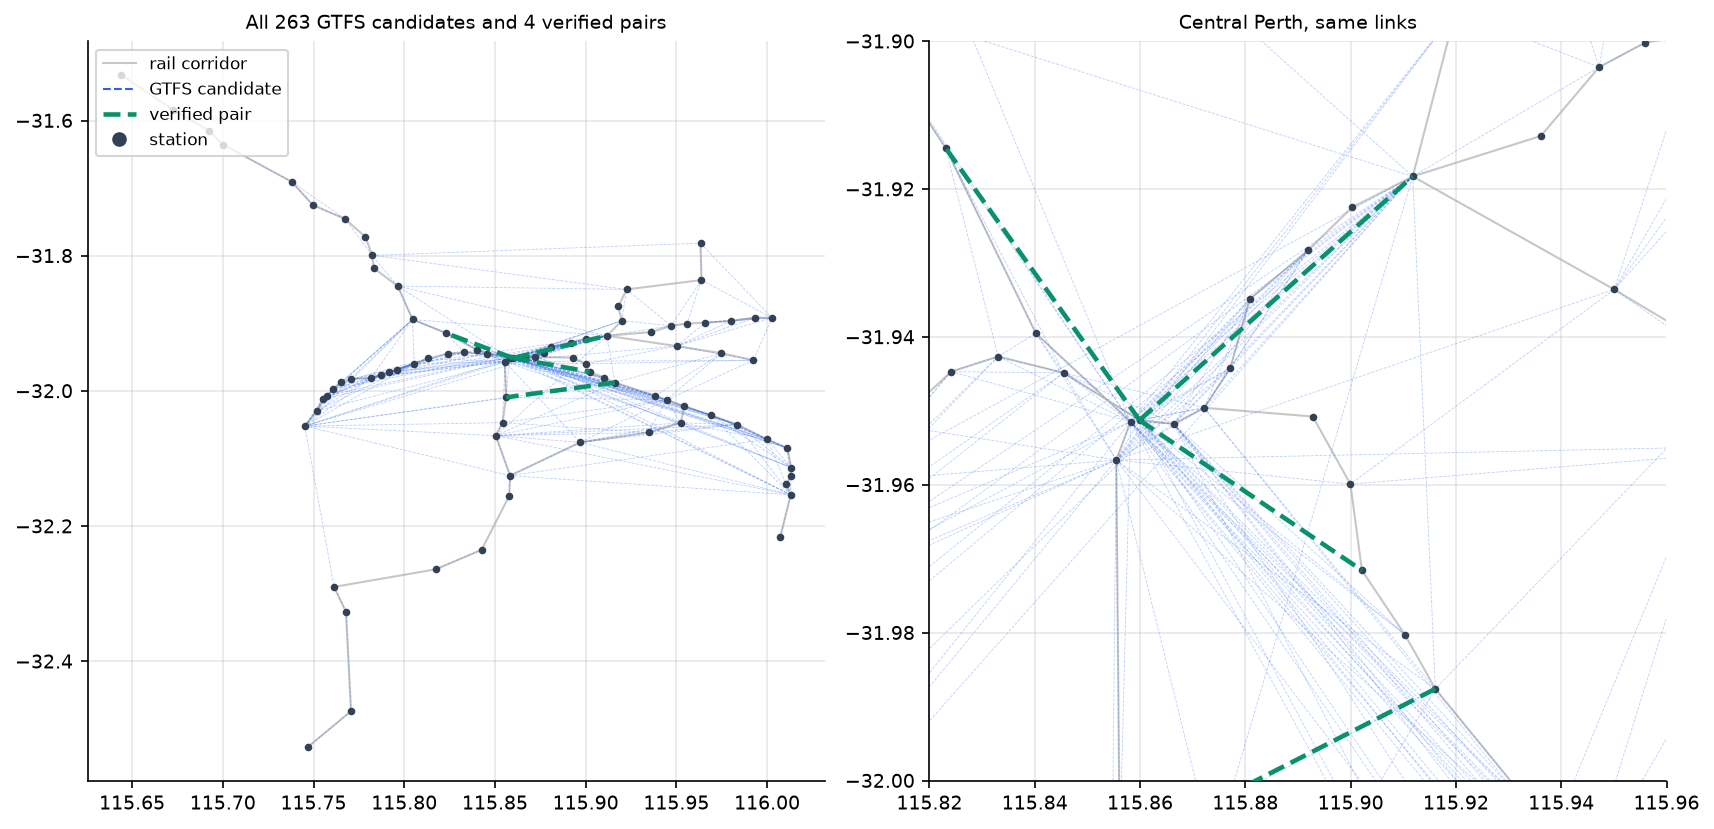

In [2]:
coords = {n: (float(d['lon']), float(d['lat'])) for n, d in rail.nodes(data=True)}
manual_pairs = [(row.station_a, row.station_b) for row in manual.itertuples()]
candidate_pairs = list(zip(candidates.station_a.astype(str), candidates.station_b.astype(str)))
rail_edges = list(rail.edges())

fig, (whole, zoom) = plt.subplots(1, 2, figsize=(11.5, 5.6))
for ax in (whole, zoom):
    for a, b in rail_edges:
        ax.plot(*zip(coords[a], coords[b]), color='0.78', lw=1.0, zorder=1)
    for a, b in candidate_pairs:
        ax.plot(*zip(coords[a], coords[b]), color='#2563eb', lw=0.4, alpha=0.30,
                ls='--', zorder=2)
    for a, b in manual_pairs:
        ax.plot(*zip(coords[a], coords[b]), color='#08916b', lw=2.2, ls='--', zorder=4)
    ax.scatter(*zip(*coords.values()), s=7, color='#334155', zorder=3)
whole.set_title(f'All {len(candidate_pairs)} GTFS candidates and 4 verified pairs', fontsize=9)
zoom.set_xlim(115.82, 115.96)
zoom.set_ylim(-32.00, -31.90)
zoom.set_title('Central Perth, same links', fontsize=9)
handles = [
    Line2D([], [], color='0.78', lw=1.0, label='rail corridor'),
    Line2D([], [], color='#2563eb', lw=1.0, ls='--', label='GTFS candidate'),
    Line2D([], [], color='#08916b', lw=2.2, ls='--', label='verified pair'),
    Line2D([], [], color='#334155', marker='o', ls='', label='station'),
]
whole.legend(handles=handles, fontsize=8, loc='upper left')
fig.tight_layout()
show_figure(fig, 'layered_network.png')

## Served service per strategy and budget

`strategy_comparison.csv` applies every P1.6 strategy to every scenario and
budget on the same failed baseline. Served OD fraction counts reachable intact
terminal pairs over the 3,655 pairs. Served demand fraction weights each pair by
the sum of its endpoint `am_peak_stops`. The travel-time penalty averages
recovered minus intact minutes over the pairs that are still reachable, so a
positive number means slower retained service. Recovery rounds count secondary
removal rounds after the closure, and zero means the closure was contained.
Rounds are algorithmic updates, not minutes.

The committed run deploys two links per strategy. The chart below shows each
strategy's change in served demand against `no_backup` on all 21 scenarios; the
worsening cases sit below the zero line. Use the controls to read one scenario
in full: the table lists all five strategies with the rail-only baseline row,
and the bars redraw the selected strategies.

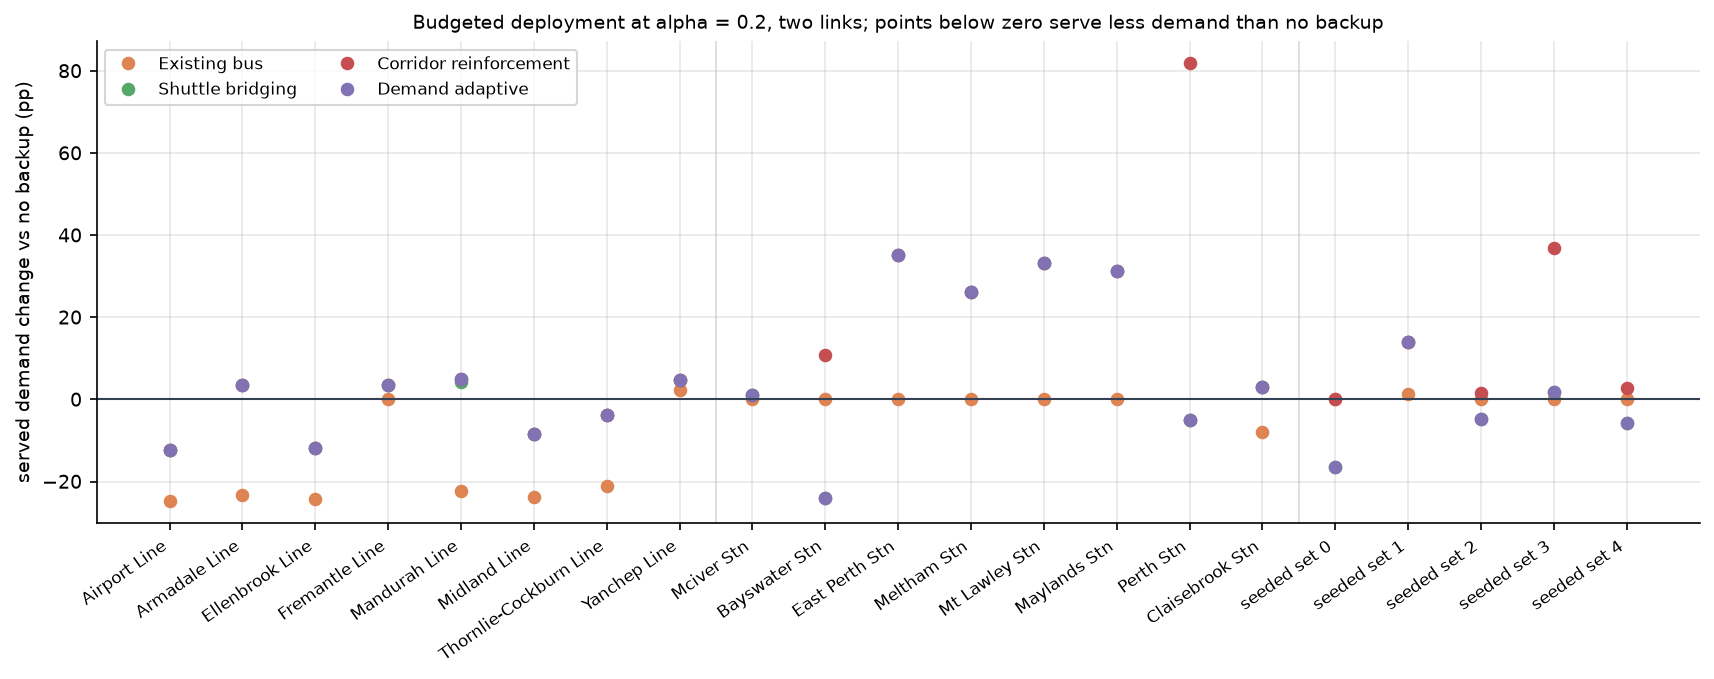

scenarios served at or above no backup, per strategy:
  Existing bus             13 / 21
  Shuttle bridging         12 / 21
  Corridor reinforcement   17 / 21
  Demand adaptive          12 / 21


In [3]:
STRATEGY_LABELS = {
    'no_backup': 'No backup',
    'existing_bus': 'Existing bus',
    'shuttle_bridging': 'Shuttle bridging',
    'corridor_reinforcement': 'Corridor reinforcement',
    'demand_adaptive': 'Demand adaptive',
}
STRATEGY_COLOURS = {
    'no_backup': '#64748b',
    'existing_bus': '#dd8452',
    'shuttle_bridging': '#55a868',
    'corridor_reinforcement': '#c44e52',
    'demand_adaptive': '#8172b3',
}
STRATEGY_ORDER = list(STRATEGY_LABELS)
KIND_ORDER = ['line_closure', 'interchange', 'random']

wide = strategy_table.pivot_table(
    index=['kind', 'scenario', 'label', 'budget'], columns='strategy',
    values='served_demand_fraction')
wide = wide.reindex(
    [index for kind in KIND_ORDER for index in wide.index if index[0] == kind])
delta_pp = 100.0 * wide.drop(columns='no_backup').sub(wide['no_backup'], axis=0)

fig, ax = plt.subplots(figsize=(11.5, 4.6))
x = np.arange(len(wide))
for strategy in STRATEGY_ORDER[1:]:
    ax.plot(x, delta_pp[strategy], 'o', ms=5.5, color=STRATEGY_COLOURS[strategy],
            label=STRATEGY_LABELS[strategy])
ax.axhline(0.0, color='#334155', lw=1.0)
for boundary in np.where(np.array([index[0] for index in wide.index])[:-1]
                         != np.array([index[0] for index in wide.index])[1:])[0] + 0.5:
    ax.axvline(boundary, color='0.85', lw=0.8, zorder=0)
ax.set_xticks(x, wide.index.get_level_values('label'), rotation=35, ha='right', fontsize=8)
ax.set_ylabel('served demand change vs no backup (pp)')
ax.set_title('Budgeted deployment at alpha = 0.2, two links; points below zero serve less demand than no backup', fontsize=9)
ax.legend(fontsize=8, ncols=2)
fig.tight_layout()
show_figure(fig, 'strategy_deltas.png')

print('scenarios served at or above no backup, per strategy:')
for strategy in STRATEGY_ORDER[1:]:
    wins = int((delta_pp[strategy] >= -1e-9).sum())
    print(f'  {STRATEGY_LABELS[strategy]:24s} {wins:2d} / {len(wide)}')

In [4]:
def scenario_rows(kind, scenario, budget):
    """Rows of one scenario and budget with the no-backup columns beside them."""
    rows = strategy_table[(strategy_table.scenario == scenario)
                          & (strategy_table.budget == budget)].copy()
    baseline = rows[rows.strategy == 'no_backup'].iloc[0]
    rows['delta_demand_pp'] = 100.0 * (rows.served_demand_fraction - baseline.served_demand_fraction)
    rows['delta_od_pp'] = 100.0 * (rows.served_od_fraction - baseline.served_od_fraction)
    table = rows[['strategy', 'selected_count', 'served_od_fraction', 'served_demand_fraction',
                  'recovery_rounds', 'secondary_failures', 'mean_travel_time_penalty_min',
                  'delta_demand_pp']].copy()
    table['strategy'] = table.strategy.map(STRATEGY_LABELS)
    return rows, table


def comparison_view(kind, scenario, budget, shown):
    rows, table = scenario_rows(kind, scenario, budget)
    if rows.empty:
        display('No rows for this scenario and budget.')
        return
    display(table.round({'served_od_fraction': 4, 'served_demand_fraction': 4,
                         'mean_travel_time_penalty_min': 3, 'delta_demand_pp': 2})
            .reset_index(drop=True))
    baseline = rows[rows.strategy == 'no_backup'].iloc[0]
    chosen = rows[rows.strategy.isin(shown)]
    fig, (left, right) = plt.subplots(1, 2, figsize=(10.5, 3.8))
    left.bar([STRATEGY_LABELS[s] for s in chosen.strategy], chosen.served_demand_fraction,
             color=[STRATEGY_COLOURS[s] for s in chosen.strategy])
    left.axhline(baseline.served_demand_fraction, color='#334155', ls='--', lw=1.0,
                 label='no backup')
    left.set(ylim=(0, 1.05), ylabel='served demand fraction')
    left.tick_params(axis='x', rotation=20)
    left.legend(fontsize=8)
    right.bar([STRATEGY_LABELS[s] for s in chosen.strategy],
              chosen.mean_travel_time_penalty_min,
              color=[STRATEGY_COLOURS[s] for s in chosen.strategy])
    right.axhline(0.0, color='#334155', lw=1.0)
    right.set(ylabel='mean travel-time penalty (min, reachable pairs)')
    right.tick_params(axis='x', rotation=20)
    left.set_title(scenario, fontsize=9)
    fig.tight_layout()
    show_figure(fig, 'interactive_comparison.png')


budgets = sorted(strategy_table.budget.unique())
kind_control = widgets.Dropdown(
    options=[('Line closure', 'line_closure'), ('Interchange', 'interchange'),
             ('Random set', 'random')], description='Scenario type:',
    layout=widgets.Layout(width='260px'))
scenario_control = widgets.Dropdown(description='Scenario:',
                                    layout=widgets.Layout(width='440px'))
budget_control = widgets.Dropdown(
    options=[(f'{b} links', b) for b in budgets], description='Budget:')
strategy_control = widgets.SelectMultiple(
    options=[(STRATEGY_LABELS[s], s) for s in STRATEGY_ORDER],
    value=tuple(STRATEGY_ORDER[1:]), description='Strategies:',
    layout=widgets.Layout(width='440px', height='120px'))


def refresh_scenarios(change=None):
    part = scenarios[scenarios.kind == kind_control.value]
    options = [(f'{row.label} ({row.n_failed} closed)', row.scenario)
               for row in part.itertuples()]
    scenario_control.options = options
    scenario_control.value = options[0][1]


kind_control.observe(refresh_scenarios, names='value')
refresh_scenarios()
output = widgets.interactive_output(
    comparison_view,
    {'kind': kind_control, 'scenario': scenario_control, 'budget': budget_control,
     'shown': strategy_control})
display(widgets.VBox([kind_control, scenario_control,
                      widgets.HBox([budget_control, strategy_control])]), output)

Output()

## The bus-aggravated cascade

The layered cascade recomputes terminal-subset loads on the surviving graph
every round and closes every rail facility above `C_i = (1 + alpha) * L0_i`,
with capacities fixed from the intact rail-only baseline
(`recovery.layered_cascade`, [docs/recovery.md](../docs/recovery.md)). Standby
buses activate after the initial closure and never prevent it.

Restored bus paths move traffic onto facilities that the rail-only run left
below their capacity. When one of those facilities crosses its threshold it
closes, and the next round shifts its load again. The scan below shows the
outcome: at low tolerance the full candidate pool closes more rail facilities
than rail-only while still serving more pairs, so recovery of connectivity and
containment of the physical cascade come apart.

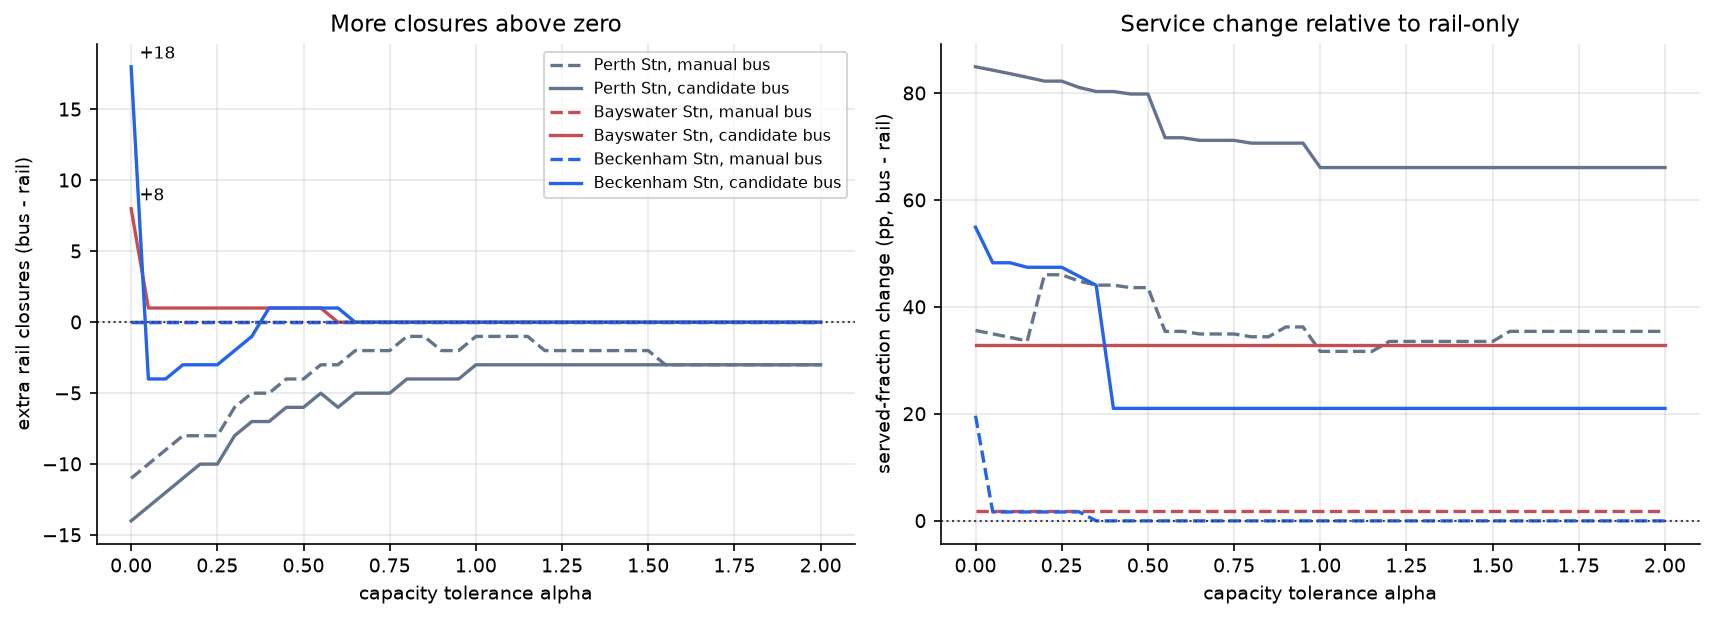

In [5]:
fig, (left, right) = plt.subplots(1, 2, figsize=(11.5, 4.2))
TRIGGER_STYLE = {56: ('#64748b', 'Perth Stn'), 23: ('#c44e52', 'Bayswater Stn'),
                 28: ('#2563eb', 'Beckenham Stn')}
for trigger, (colour, name) in TRIGGER_STYLE.items():
    for scenario, style in [('manual_bus', '--'), ('candidate_bus', '-')]:
        part = comparison[(comparison.trigger == trigger) & (comparison.scenario == scenario)] \
            .sort_values('alpha')
        left.plot(part.alpha, part.delta_n_failed, style, color=colour, lw=1.6,
                  label=f'{name}, {scenario.replace("_", " ")}')
        # Served fraction is 1 - unmet fraction, so its paired delta has the opposite sign.
        right.plot(part.alpha, -100.0 * part.delta_unmet_fraction, style, color=colour, lw=1.6,
                   label=f'{name}, {scenario.replace("_", " ")}')
        worst = part.loc[part.delta_n_failed.idxmax()]
        if worst.delta_n_failed > 0:
            left.annotate(f'{int(worst.delta_n_failed):+d}', (worst.alpha, worst.delta_n_failed),
                          textcoords='offset points', xytext=(4, 4), fontsize=8)
left.axhline(0.0, color='#334155', lw=1.0, ls=':')
left.set(xlabel='capacity tolerance alpha', ylabel='extra rail closures (bus - rail)',
         title='More closures above zero')
right.axhline(0.0, color='#334155', lw=1.0, ls=':')
right.set(xlabel='capacity tolerance alpha', ylabel='served-fraction change (pp, bus - rail)',
          title='Service change relative to rail-only')
handles, labels = left.get_legend_handles_labels()
left.legend(handles, labels, fontsize=7.5)
fig.tight_layout()
show_figure(fig, 'bus_cascade_deltas.png')

## Inside one traced cascade

The loads table stores every surviving facility at each round of the traced
cases. A row reports the load recomputed after the previous round's closures,
the fixed capacity from the intact rail-only baseline, and whether the facility
closes next round. Round 0 is the first check after the initial closure.

Pick a trigger, bus set and tolerance from the traced cases. The left panel
draws the load-to-capacity ratio of every facility that closes during the run
and the round where it crosses one. The right panel counts the new closures per
round.

In [6]:
TRIGGER_NAMES = {56: 'Perth Stn', 23: 'Bayswater Stn', 28: 'Beckenham Stn'}
SCENARIO_LABELS = {'rail_only': 'rail only', 'manual_bus': '4 verified pairs',
                   'candidate_bus': 'full candidate pool'}


def mechanism_view(trigger, scenario, alpha):
    case_loads = loads[(loads.trigger == trigger) & (loads.scenario == scenario)
                       & np.isclose(loads.alpha, alpha)]
    case_history = history[(history.trigger == trigger) & (history.scenario == scenario)
                           & np.isclose(history.alpha, alpha)].sort_values('round')
    case_scan = scan[(scan.trigger == trigger) & (scan.scenario == scenario)
                     & np.isclose(scan.alpha, alpha)]
    delta = comparison[(comparison.trigger == trigger) & (comparison.scenario == scenario)
                       & np.isclose(comparison.alpha, alpha)]
    name = TRIGGER_NAMES[trigger]
    label = SCENARIO_LABELS[scenario]
    closed = case_loads[case_loads.overloaded]
    rows = max(closed.name.nunique(), 1)
    fig, (left, right) = plt.subplots(1, 2, figsize=(11.5, max(4.2, 0.30 * rows + 1.8)))
    if closed.empty:
        headroom = case_loads[case_loads['round'] == 0].nlargest(8, 'load_ratio').iloc[::-1]
        left.barh(headroom.name, headroom.load_ratio, color='#94a3b8')
        left.axvline(1.0, color='#dc2626', ls='--', label='fixed capacity')
        left.set(xlabel='load / fixed capacity at the first check',
                 title=f'{name}, {label}: no facility crossed its capacity')
        left.legend(fontsize=8)
    else:
        order = closed.groupby('name')['round'].min().sort_values()
        y = {station: index for index, station in enumerate(order.index)}
        scatter = left.scatter(closed['round'], closed.name.map(y), c=closed.load_ratio,
                               cmap='YlOrRd', vmin=0.9,
                               vmax=max(float(closed.load_ratio.max()), 1.2),
                               s=75, edgecolors='#334155', linewidths=0.6, zorder=3)
        for row in closed.sort_values('round').itertuples(index=False):
            left.annotate(f'{row.load_ratio:.2f}', (row.round, y[row.name]),
                          textcoords='offset points', xytext=(0, 8), ha='center', fontsize=6.5)
        left.set_yticks(list(y.values()), list(y.keys()), fontsize=8)
        left.set(xlabel='round (0 = first check after the closure)',
                 title=f'{name}, {label}: load / fixed capacity')
        fig.colorbar(scatter, ax=left, label='load / fixed capacity', fraction=0.04)

    new_closures = [0 if pd.isna(value) or value == '' else len(str(value).split(';'))
                    for value in case_history.next_failed_ids]
    right.bar(case_history['round'], new_closures, color='#c44e52', width=0.55)
    right.set_xticks(range(int(case_history['round'].max()) + 1))
    right.set(xlabel='round', ylabel='new rail closures',
              ylim=(0, max(new_closures + [1]) + 1))
    right.set_title(f'{name}, {label}: closures per round', fontsize=9)
    message = (f'alpha = {alpha:g}; rail facilities closed including the trigger: '
               f'{int(case_scan.n_failed.iloc[0]) if not case_scan.empty else "?"}')
    if not delta.empty:
        message += f', extra against rail-only: {int(delta.delta_n_failed.iloc[0]):+d}'
    fig.suptitle(message, fontsize=9)
    fig.tight_layout()
    show_figure(fig, 'mechanism_rounds.png')

    closure_log = []
    for row in case_history.itertuples(index=False):
        if pd.isna(row.next_failed_ids) or row.next_failed_ids == '':
            names = '-'
        else:
            names = '; '.join(rail.nodes[i]['name']
                              for i in str(row.next_failed_ids).split(';'))
        closure_log.append({'round': row.round, 'new closures': names,
                            'secondary closures so far': row.n_secondary})
    display(pd.DataFrame(closure_log))


trigger_control = widgets.Dropdown(options=[(v, k) for k, v in TRIGGER_NAMES.items()],
                                   value=23, description='Trigger:')
scenario_control_bus = widgets.Dropdown(
    options=[(label, key) for key, label in SCENARIO_LABELS.items()],
    value='candidate_bus', description='Bus set:')
alpha_control = widgets.Dropdown(options=[0.0, 0.2], value=0.0, description='Alpha:')
output = widgets.interactive_output(
    mechanism_view,
    {'trigger': trigger_control, 'scenario': scenario_control_bus, 'alpha': alpha_control})
display(widgets.HBox([trigger_control, scenario_control_bus, alpha_control]), output)

Output()

## The budgeted Airport Line case

A budgeted selection can also lower served service. After the three exclusive
Airport Line facilities close, `existing_bus` spends its two links on routes
that end with West Leederville above capacity, so it closes as well. The table
below lists the five strategies with their added closures and served fractions;
the figure puts the served OD and served demand fractions beside the rail-only
baseline.

,strategy,selected_count,served_od_fraction,served_demand_fraction,recovery_rounds,secondary_failures,added
0,No backup,0,0.9311,0.9450,0,0,
1,Existing bus,2,0.6668,0.6965,1,1,West Leederville Stn
2,Shuttle bridging,2,0.7803,0.8226,1,7,Guildford Stn; Success Hill Stn; Bassendean St...
3,Corridor reinforcement,2,0.7803,0.8226,1,7,Guildford Stn; Success Hill Stn; Bassendean St...
4,Demand adaptive,2,0.7803,0.8226,1,7,Guildford Stn; Success Hill Stn; Bassendean St...


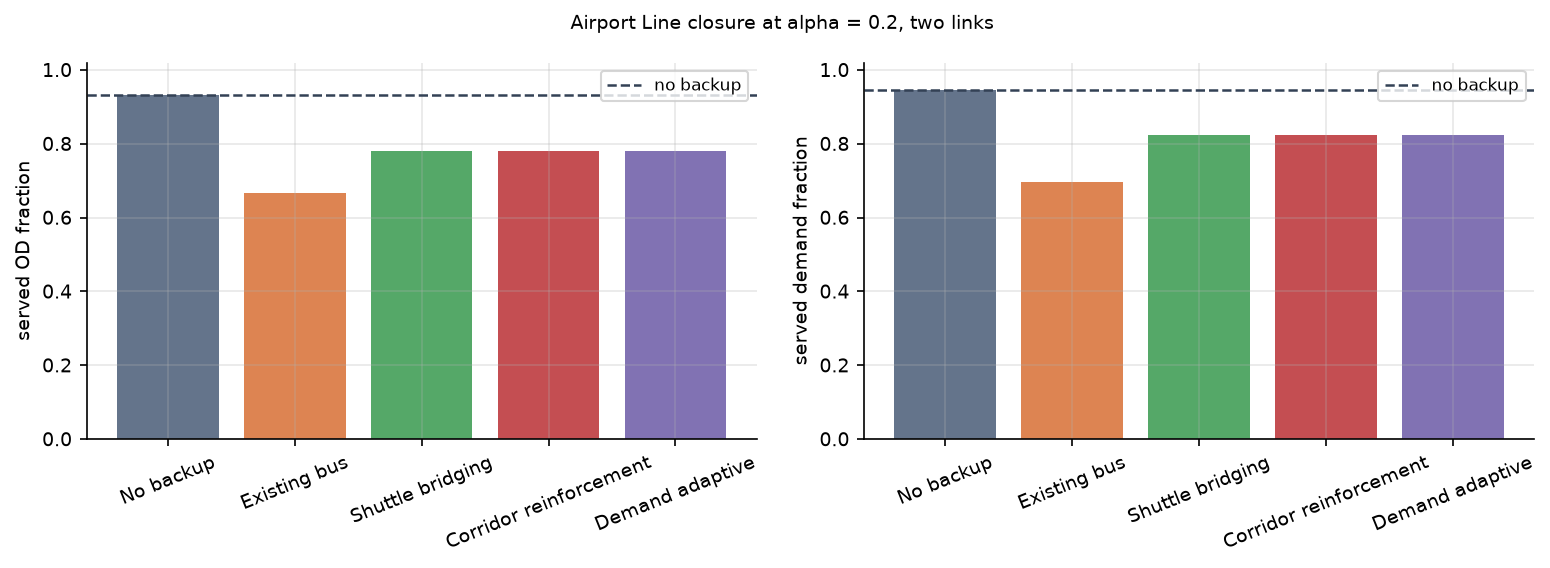

In [7]:
airport = strategy_table[strategy_table.scenario == 'line_closure:Airport Line'].copy()
initial = set(str(scenarios.loc[scenarios.scenario == 'line_closure:Airport Line',
                                'failed_ids'].iloc[0]).split(';'))
airport['added'] = airport.failed_after_cascade.map(
    lambda ids: '; '.join(rail.nodes[i]['name'] for i in ids.split(';')
                          if i not in initial))
airport['colour'] = airport.strategy.map(STRATEGY_COLOURS)
airport['strategy'] = airport.strategy.map(STRATEGY_LABELS)
display_order = {STRATEGY_LABELS[key]: index for index, key in enumerate(STRATEGY_ORDER)}
airport = airport.sort_values('strategy', key=lambda labels: labels.map(display_order))
display(airport[['strategy', 'selected_count', 'served_od_fraction', 'served_demand_fraction',
                 'recovery_rounds', 'secondary_failures', 'added']]
        .round({'served_od_fraction': 4, 'served_demand_fraction': 4})
        .reset_index(drop=True))

baseline = airport[airport.strategy == 'No backup'].iloc[0]
fig, (left, right) = plt.subplots(1, 2, figsize=(10.5, 3.8))
for ax, column, label in [(left, 'served_od_fraction', 'served OD fraction'),
                          (right, 'served_demand_fraction', 'served demand fraction')]:
    ax.bar(airport.strategy, airport[column], color=airport.colour)
    ax.axhline(baseline[column], color='#334155', ls='--', lw=1.2, label='no backup')
    ax.set(ylim=(0, 1.02), ylabel=label)
    ax.tick_params(axis='x', rotation=22)
    ax.legend(fontsize=8)
fig.suptitle('Airport Line closure at alpha = 0.2, two links', fontsize=9)
fig.tight_layout()
show_figure(fig, 'airport_case.png')

## What the recovery layer adds to RQ3

The bus layer restores reachable terminal pairs, and the full standby pool
improves served service on most scenarios. The physical cascade behaves
differently: with capacities fixed from the rail-only baseline, added paths can
push a facility above its threshold and close it, and that extra closure can
cost more service than the buses recover. The Airport Line row above is the
clearest case, and the Bayswater and Beckenham scans show the same mechanism
without the budget. No strategy dominates: the overview chart counts losses for
each of the five, and corridor reinforcement has the fewest.

These are scenario results on four verified pairs plus GTFS co-occurrence
candidates, unlimited standby capacity and an endpoint-sum demand proxy. They
describe how this model behaves, not how Transperth would reroute buses on a
given morning. Definitions and assumptions are in
[docs/recovery.md](../docs/recovery.md) and [docs/model.md](../docs/model.md).

Reproduce with `make recovery PYTHON=.venv/bin/python`; this notebook reads the
committed output and copies every chart to `figures/notebook04/`. Notebook 03
ends with the rail-only cascade, and this notebook closes the demonstration
with the recovery result.

In [8]:
print(f'Notebook computation: {time.perf_counter() - started:.2f} seconds')

Notebook computation: 2.02 seconds
